# 서울시 따릉이 대여소 인프라와 운영 효율 분석

## 1. 배경
서울시의 공공자전거 '따릉이' 데이터를 활용하여 자치구별 대여소 운영 현황을 파악하고, 인프라의 규모가 운영 효율에 미치는 영향을 분석합니다.

## 2. 가설 설정
- **가설 1**: 대여소가 많은 자치구일수록 대여소 1개당 대여건수(효율)가 높을 것이다. (네트워크 효과 존재 여부 확인)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 폰트 설치
!apt-get -qq install fonts-nanum

# 2. 폰트 파일 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

# 3. Matplotlib에 폰트 등록
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 4. 폰트 매니저에 명시적으로 추가
fm.fontManager.addfont(font_path)

PATH = '/content/drive/MyDrive/data/'
print(f'설정된 폰트: {font_name}')

Mounted at /content/drive
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
설정된 폰트: NanumGothic


In [8]:
df = pd.read_csv(PATH + '따릉이_분석용.csv', encoding='utf-8')
# 한글 깨지면 encoding='euc-kr' 또는 'utf-8' 시도

print(f'데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열')

데이터 크기: 13,795행 × 8열


In [ ]:
df.head()

,자치구,대여소명,기준년월,대여건수,반납건수,위도,경도,거치대수
0,마포구,108. 서교동 사거리,202507,1277,1314,37.544582,127.044609,10.0
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808,37.481491,126.981583,NaN
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218,37.486835,126.968048,NaN
3,양천구,733. 신정이펜하우스314동,202507,876,375,37.494499,126.916527,NaN
4,양천구,734. 신트리공원 입구,202507,2987,2958,37.688274,127.049065,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13795 entries, 0 to 13794
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   자치구     13795 non-null  object 
 1   대여소명    13795 non-null  object 
 2   기준년월    13795 non-null  int64  
 3   대여건수    13795 non-null  int64  
 4   반납건수    13795 non-null  int64  
 5   위도      9030 non-null   float64
 6   경도      9030 non-null   float64
 7   거치대수    8532 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 862.3+ KB


In [ ]:
df.describe()

,기준년월,대여건수,반납건수,위도,경도,거치대수
count,13795.000000,13795.000000,13795.000000,9030.000000,9030.000000,8532.000000
mean,202509.004857,1281.811381,1274.877057,36.444838,123.251830,11.856892
std,1.414436,1168.443209,1217.389708,6.349873,21.473883,6.019371
min,202507.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,202508.000000,515.000000,455.000000,37.503815,126.912987,9.000000
50%,202509.000000,950.000000,941.000000,37.546841,127.001480,10.000000
75%,202510.000000,1668.000000,1697.000000,37.581314,127.059212,14.000000
max,202511.000000,17664.000000,18654.000000,37.692322,127.177010,62.000000


In [ ]:
print(df.columns.tolist())

['자치구', '대여소명', '기준년월', '대여건수', '반납건수', '위도', '경도', '거치대수']


In [ ]:
print(df['자치구'].unique())
#자치구에서 중복제거해서 보여줘
print(f'자치구 수: {df['자치구'].nunique()}개')
#자치구의 개수를 자치구수 뒤에 적어줘

['마포구' '양천구' '광진구' '은평구' '성동구' '강동구' '강서구' '송파구' '중랑구' '강북구' '노원구' '도봉구'
 '금천구' '동작구' '관악구' '서초구' '중구' '종로구' '강남구' '서대문구' '성북구' '구로구' '동대문구' '영등포구'
 '용산구']
자치구 수: 25개


In [ ]:
print(df['자치구'].unique())
#자치구에서 중복제거해서 보여줘

['마포구' '양천구' '광진구' '은평구' '성동구' '강동구' '강서구' '송파구' '중랑구' '강북구' '노원구' '도봉구'
 '금천구' '동작구' '관악구' '서초구' '중구' '종로구' '강남구' '서대문구' '성북구' '구로구' '동대문구' '영등포구'
 '용산구']


In [ ]:
print(df.shape)
#행과 열의 수 알려줘

(13795, 8)


In [ ]:
df.isnull().sum()
#빈 칸이 몇개인지 알려줘

,0
자치구,0
대여소명,0
기준년월,0
대여건수,0
반납건수,0
위도,4765
경도,4765
거치대수,5263


In [ ]:
df.sort_values('대여건수', ascending=False).head(5)[['대여소명', '자치구', '대여건수']]
#대여건수 기준으로 내림차순정렬로 상위 5개만. 대여소명, 자치구, 대여건수만 선택해서 보여줘

,대여소명,자치구,대여건수
6383,2715.마곡나루역 2번 출구,강서구,17664
889,2715.마곡나루역 2번 출구,강서구,15460
3633,2715.마곡나루역 2번 출구,강서구,15117
9140,2715.마곡나루역 2번 출구,강서구,14782
11906,2715.마곡나루역 2번 출구,강서구,14217


In [12]:
영등포 = df[df['자치구'] == '영등포구']
#자치구가 영등포구인 것만 영등포로 저장
print(f'영등포구 대여소: {len(영등포)}개')
#영등포 갯수를 영등포구 대여소 뒤에 적어줘

영등포구 대여소: 849개


In [13]:
거치대없음 = df[df['거치대수'] == 0]
#거치대수가 0인것만 거치대없음으로 저장
print(f'{len(거치대없음)}개')
#거치대없음이 몇 개인지 보여줘
거치대없음[['대여소명', '자치구']]
#거치대 없음에서 대여소명과 자치구만 보여줘

0개


,대여소명,자치구


In [14]:
df.groupby('자치구').size().sort_values(ascending=False)
# 자치구를 그룹으로 묶어서 개수를 세어서 내림차순(많은 것)으로 정렬해서 보여줘
df['자치구'].value_counts()
#자치구에서 개수 많은 순으로 보여줘

,count
자치구,
송파구,1096
강서구,966
강남구,851
영등포구,849
노원구,755
서초구,723
마포구,601
강동구,601
구로구,574


In [15]:
gu_rent = df.groupby('자치구')['대여건수'].sum().sort_values(ascending=False)
#자치구를 그룹별로 묶고 대여건수만 더해서 내림차순으로 정렬한 것을 gu_rent로 저장
print(gu_rent)
# gu_rent보여줘
print(f'\n1위: {gu_rent.index[0]} ({gu_rent.iloc[0]:,}건)')
#인덱스의 첫번째 자치구와 첫번째수(천단위에 ,사용)를 1위로 해서 보여줘

자치구
강서구     2200391
송파구     1644794
영등포구    1630819
양천구     1095806
노원구     1046746
강동구      844581
마포구      838684
광진구      838194
구로구      725741
성동구      656857
강남구      611453
동대문구     582291
종로구      569590
서초구      535191
중랑구      478850
중구       418676
은평구      404271
도봉구      371256
성북구      356768
용산구      350394
관악구      345402
서대문구     321144
동작구      306411
금천구      291549
강북구      216729
Name: 대여건수, dtype: int64

1위: 강서구 (2,200,391건)


In [16]:
# 자치구별 대여건수 합계와 대여소명 개수(중복 제외) 계산
gu_stats = df.groupby('자치구').agg(
    #자치구를 그룹으로 묶고 하나의 값으로 요약한것을 gu_stats로 저장
    대여건수_합계=('대여건수', 'sum'),
    #대여건수와 합계는 대여건수_합계로
    대여소_개수=('대여소명', 'nunique')
    #대여소명과 개수는 대여소_개수로
).sort_values('대여건수_합계', ascending=False)
#대여건수_합계를 내림차순러 장렬헤줘

# 결과 출력
display(gu_stats)
#gu_stats를 보여줘

,대여건수_합계,대여소_개수
자치구,,
강서구,2200391,197
송파구,1644794,221
영등포구,1630819,173
양천구,1095806,111
노원구,1046746,152
강동구,844581,121
마포구,838684,121
광진구,838194,89
구로구,725741,115


In [17]:
# 대여소 1개당 대여건수 계산
gu_stats['대여소1개당_대여건수'] = gu_stats['대여건수_합계'] / gu_stats['대여소_개수']
#자치구별 대여건수를 대여소 개수로 나눈 것을 gu_stats['대여소1개당_대여건수']로 저장
# 평균 대여건수가 높은 순으로 정렬하여 출력
display(gu_stats.sort_values('대여소1개당_대여건수', ascending=False))
#gu_stats에서 대여소 1개당 대여건수를 기준으로 내림차순으로 정렬해서 보여줘

,대여건수_합계,대여소_개수,대여소1개당_대여건수
자치구,,,
강서구,2200391,197,11169.497462
양천구,1095806,111,9872.126126
영등포구,1630819,173,9426.699422
광진구,838194,89,9417.910112
송파구,1644794,221,7442.506787
강동구,844581,121,6980.008264
마포구,838684,121,6931.272727
노원구,1046746,152,6886.486842
성동구,656857,96,6842.260417


In [18]:
import pandas as pd
#데이터를 판다스로 불러와서 pd라고 쓴다
# 자치구별 대여건수 합계와 대여소 개수 계산
gu_stats = df.groupby('자치구').agg(
    #자치구를 그룹으로 묶어서 집계한 것을 gu_stats로 저장
    대여건수_합계=('대여건수', 'sum'),
    #대여건수와 합계는 대여건수_합계로
    대여소_개수=('대여소명', 'nunique')
)
# 대여소명과 개수는 대여소_개수로 집계

# 대여소 1개당 대여건수 계산
gu_stats['대여소1개당_대여건수'] = gu_stats['대여건수_합계'] / gu_stats['대여소_개수']
#대여소1개당_대여건수는 대여건수를 대여소 개수로 나눈것으로 저장
# 순위 매기기
gu_stats['대여효율_순위'] = gu_stats['대여소1개당_대여건수'].rank(ascending=False, method='min').astype(int)
#gu_stats의 대여소 1개당 대여건수를 내림차순으로 가장작은 수(1)로, 동점자는 가장 높은 순위 랭크를 매긴다. 정수형으로 변환해서 gu_stats['대여효율_순위']로 저장
gu_stats['대여소수_순위'] = gu_stats['대여소_개수'].rank(ascending=False, method='min').astype(int)
#gu_stats의 대여소_개수를 내림차순으로 가장작은 수(1)로, 동점자는 가장 높은 순위 랭크를 매긴다. 정수형으로 변환해서 gu_stats['대여소수_순']로 저장
# 대여효율(대여소1개당 대여건수) 높은 순으로 정렬
ranking = gu_stats.sort_values('대여효율_순위')
#대여효율순위를 정렬해서 ranking 으로 저장
# 결과 출력
display(ranking[['대여효율_순위', '대여소1개당_대여건수', '대여소수_순위', '대여소_개수']])
#대여효율순위, 대여소 1개당 대여건수, 대여소 개수 랭킹을 보여줘

,대여효율_순위,대여소1개당_대여건수,대여소수_순위,대여소_개수
자치구,,,,
강서구,1,11169.497462,2,197
양천구,2,9872.126126,10,111
영등포구,3,9426.699422,4,173
광진구,4,9417.910112,17,89
송파구,5,7442.506787,1,221
강동구,6,6980.008264,7,121
마포구,7,6931.272727,7,121
노원구,8,6886.486842,5,152
성동구,9,6842.260417,12,96


/tmp/ipykernel_9267/2684570187.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranking.index, y='대여소1개당_대여건수', data=ranking, palette='viridis')


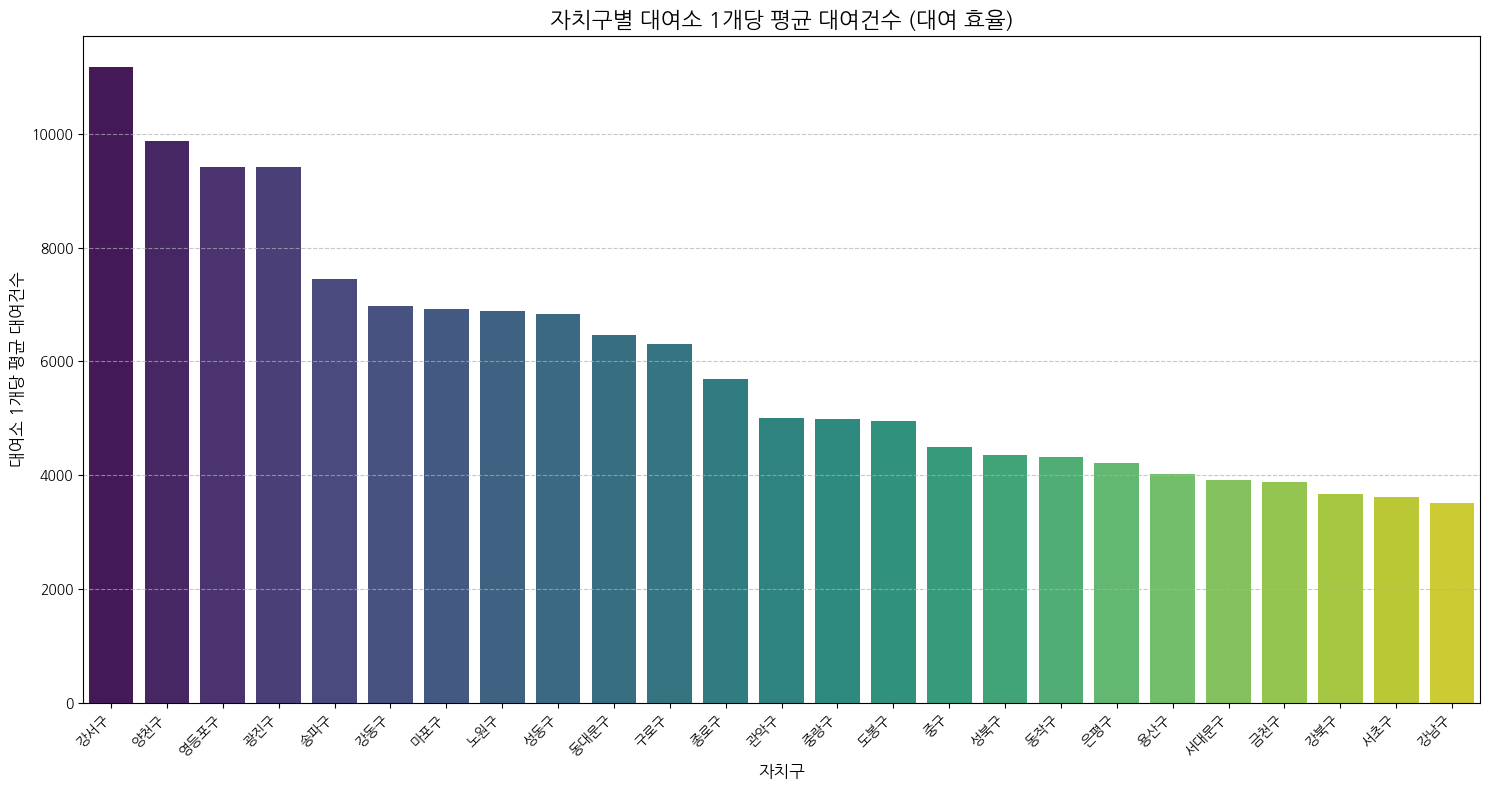

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 대여소 1개당 대여건수를 막대 그래프로 시각화
plt.figure(figsize=(15, 8))
sns.barplot(x=ranking.index, y='대여소1개당_대여건수', data=ranking, palette='viridis')
plt.title('자치구별 대여소 1개당 평균 대여건수 (대여 효율)', fontsize=16)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('대여소 1개당 평균 대여건수', fontsize=12)
plt.xticks(rotation=45, ha='right') # x축 레이블 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

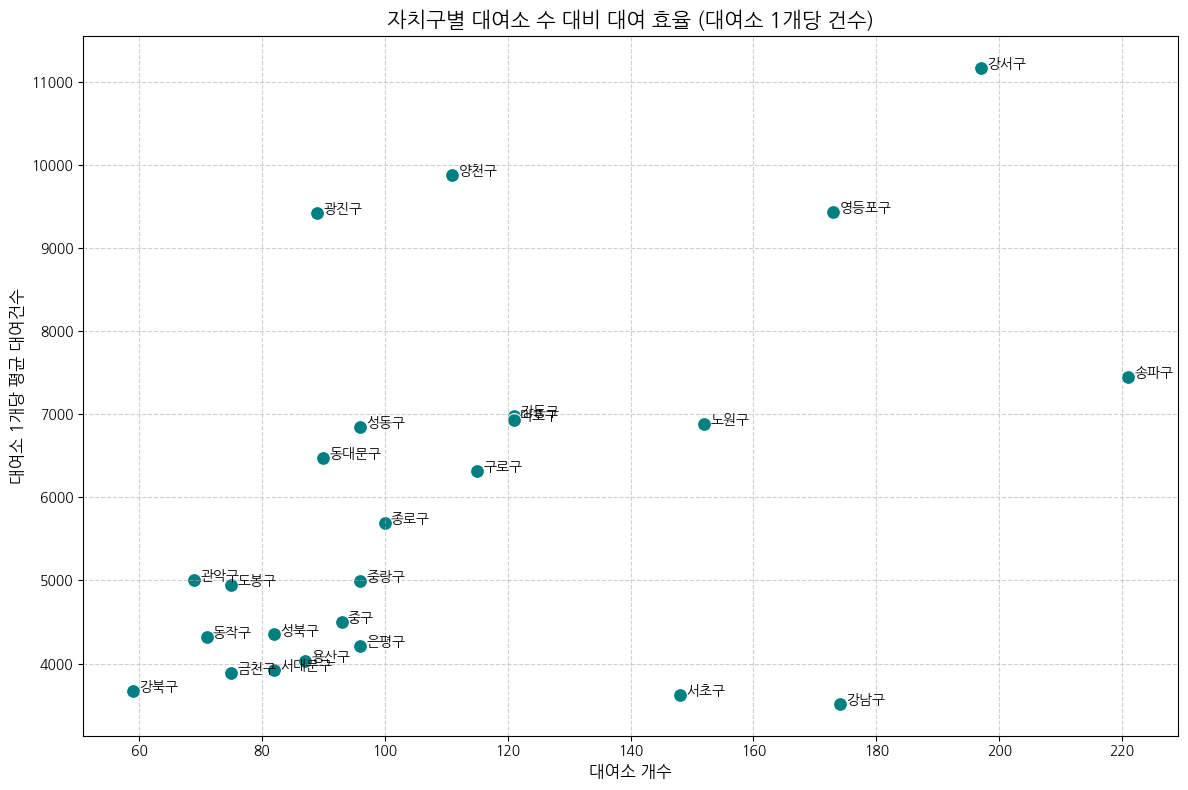

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 산점도를 통한 대여소 수 대비 효율 시각화
plt.figure(figsize=(12, 8))
sns.scatterplot(x='대여소_개수', y='대여소1개당_대여건수', data=ranking, s=100, color='teal')

# 각 점에 자치구 이름 표시
for i in range(len(ranking)):
    plt.text(ranking['대여소_개수'].iloc[i]+1, ranking['대여소1개당_대여건수'].iloc[i], ranking.index[i], fontsize=10)

plt.title('자치구별 대여소 수 대비 대여 효율 (대여소 1개당 건수)', fontsize=15)
plt.xlabel('대여소 개수', fontsize=12)
plt.ylabel('대여소 1개당 평균 대여건수', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# 자치구별 대여소 수와 대여 효율(1개당 대여건수) 표 출력
display(ranking[['대여소_개수', '대여소1개당_대여건수', '대여효율_순위']].sort_values('대여효율_순위'))

,대여소_개수,대여소1개당_대여건수,대여효율_순위
자치구,,,
강서구,197,11169.497462,1
양천구,111,9872.126126,2
영등포구,173,9426.699422,3
광진구,89,9417.910112,4
송파구,221,7442.506787,5
강동구,121,6980.008264,6
마포구,121,6931.272727,7
노원구,152,6886.486842,8
성동구,96,6842.260417,9


### 가설 검증: 대여소 수와 대여 효율 간의 상관관계 분석
- **가설**: 대여소가 많은 자치구일수록 대여소 1개당 대여건수(효율)가 높을 것이다.
- **분석 방법**: 피어슨 상관계수 산출 및 회귀선 시각화

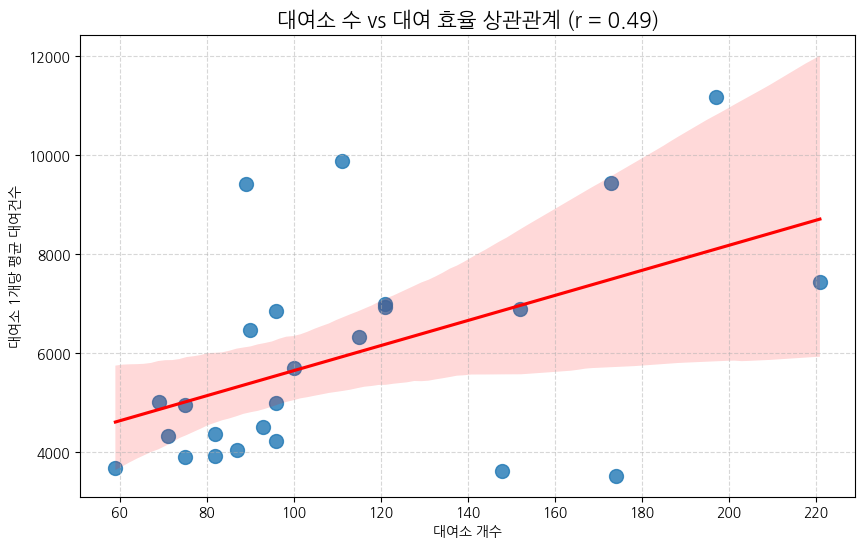

피어슨 상관계수: 0.4931
p-value: 0.0123
결과: 어느 정도 양의 상관관계가 있으나, 다른 요인도 중요해 보입니다.


In [ ]:
import scipy.stats as stats

# 상관계수 계산
correlation, p_value = stats.pearsonr(ranking['대여소_개수'], ranking['대여소1개당_대여건수'])

# 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='대여소_개수', y='대여소1개당_대여건수', data=ranking, scatter_kws={'s':100}, line_kws={'color':'red'})

plt.title(f'대여소 수 vs 대여 효율 상관관계 (r = {correlation:.2f})', fontsize=15)
plt.xlabel('대여소 개수')
plt.ylabel('대여소 1개당 평균 대여건수')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"피어슨 상관계수: {correlation:.4f}")
print(f"p-value: {p_value:.4f}")

if correlation > 0.7:
    print('결과: 강한 양의 상관관계가 있습니다. 가설이 매우 설득력이 있습니다.')
elif correlation > 0.3:
    print('결과: 어느 정도 양의 상관관계가 있으나, 다른 요인도 중요해 보입니다.')
else:
    print('결과: 상관관계가 낮거나 없습니다. 대여소 수와 효율은 독립적일 가능성이 큽니다.')

### 추가 검증 1: 대여소 수 규모에 따른 효율성 그룹 비교
대여소 개수를 기준으로 자치구를 3개 그룹(상, 중, 하)으로 나누어 실제 효율의 분포 차이를 확인합니다.

/tmp/ipykernel_25232/3086806206.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='규모_그룹', y='대여소1개당_대여건수', data=ranking, palette='Set3')


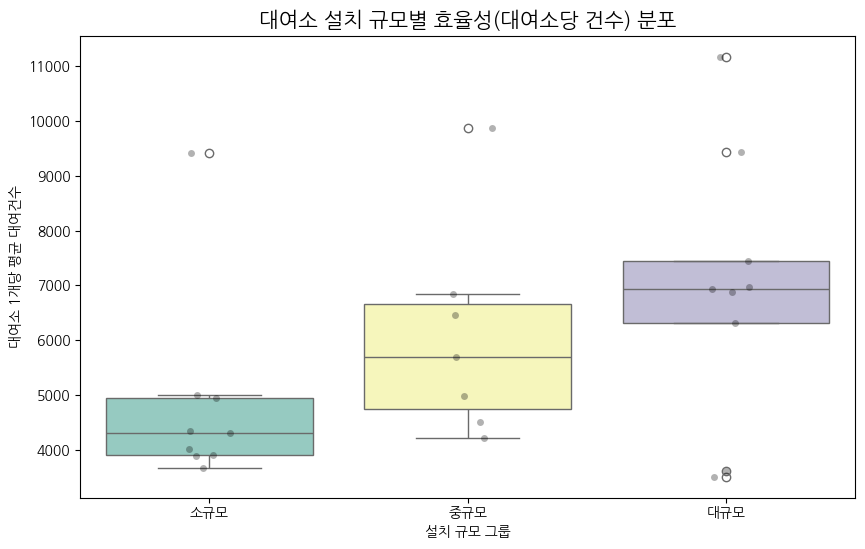

그룹별 평균 효율:
규모_그룹
소규모    4838.321525
중규모    6083.036586
대규모    6919.723991
Name: 대여소1개당_대여건수, dtype: float64


/tmp/ipykernel_25232/3086806206.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mean = ranking.groupby('규모_그룹')['대여소1개당_대여건수'].mean()


In [ ]:
# 대여소 수를 기준으로 3개 그룹으로 분할
ranking['규모_그룹'] = pd.qcut(ranking['대여소_개수'], q=3, labels=['소규모', '중규모', '대규모'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='규모_그룹', y='대여소1개당_대여건수', data=ranking, palette='Set3')
sns.stripplot(x='규모_그룹', y='대여소1개당_대여건수', data=ranking, color='black', alpha=0.3)

plt.title('대여소 설치 규모별 효율성(대여소당 건수) 분포', fontsize=15)
plt.xlabel('설치 규모 그룹')
plt.ylabel('대여소 1개당 평균 대여건수')
plt.show()

# 그룹별 평균값 확인
group_mean = ranking.groupby('규모_그룹')['대여소1개당_대여건수'].mean()
print("그룹별 평균 효율:")
print(group_mean)

### 추가 검증 2: 사분면 분석 (Quadrant Analysis)
평균 대여소 수와 평균 효율을 기준으로 자치구의 위치를 분석하여 가설을 벗어나는 자치구를 식별합니다.

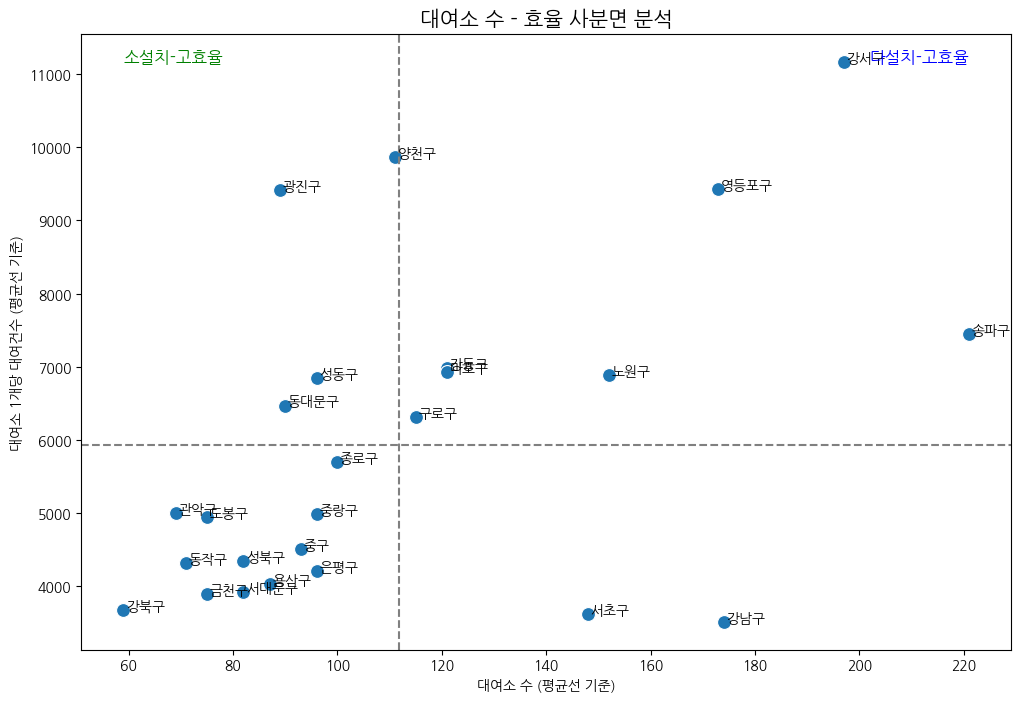

In [ ]:
mean_count = ranking['대여소_개수'].mean()
mean_eff = ranking['대여소1개당_대여건수'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(x='대여소_개수', y='대여소1개당_대여건수', data=ranking, s=100)

# 기준선 그리기 (평균값)
plt.axvline(mean_count, color='gray', linestyle='--')
plt.axhline(mean_eff, color='gray', linestyle='--')

# 자치구 레이블 추가
for i in range(len(ranking)):
    plt.text(ranking['대여소_개수'].iloc[i]+0.5, ranking['대여소1개당_대여건수'].iloc[i], ranking.index[i])

plt.title('대여소 수 - 효율 사분면 분석', fontsize=15)
plt.xlabel('대여소 수 (평균선 기준)')
plt.ylabel('대여소 1개당 대여건수 (평균선 기준)')

# 사분면 설명 추가
plt.text(ranking['대여소_개수'].max(), ranking['대여소1개당_대여건수'].max(), '다설치-고효율', color='blue', fontsize=12, ha='right')
plt.text(ranking['대여소_개수'].min(), ranking['대여소1개당_대여건수'].max(), '소설치-고효율', color='green', fontsize=12)

plt.show()

### 가설 1 검증 결과
- **상관계수**: 약 0.49 (양의 상관관계 존재)
- **그룹별 효율**: 소규모(4,838건) < 중규모(6,083건) < 대규모(6,919건)
- **결과**: **가설은 대체로 일치함**. 대여소 인프라가 대규모인 자치구가 소규모인 곳보다 약 43% 높은 운영 효율을 보임.

---

## 4. 결론

### 발견한 것 (숫자로!)
1. **인프라 규모와 효율**: 대여소 대규모 그룹은 소규모 그룹 대비 대여소당 평균 대여 건수가 **약 2,081건(43%)** 더 높음.
2. **최고 효율 자치구**: **강서구**가 대여소 1개당 약 **11,169건**으로 서울시 전체 1위를 차지함.
3. **상관성**: 대여소 수와 효율 간의 상관계수는 **0.493**으로, 인프라 확충이 이용률 증대에 긍정적 영향을 미침을 확인함.

### 서울시에 제안
- **양천구·광진구 인프라 확충**: 대여소 수는 적으나 효율(대여소당 건수)이 높은 '고효율-소설치' 지역이므로, 대여소를 추가 설치할 경우 이용객이 더 빠르게 증가할 가능성이 높음.
- **강남·서초구 운영 전략 재검토**: 대여소 수는 많으나 효율이 낮은 지역은 자전거 전용도로 확충이나 대여소 위치 재조정 등 질적 개선이 필요함.

### 한계점
- 자치구의 면적이나 인구 밀도, 지하철역과의 거리 등 대외적인 변수를 모두 통제하지 못한 한계가 있음.
- 이용 시간대별 데이터가 아닌 월간 누적 데이터를 사용함.